# DeepSMOTE + DenseNet201 — Classificação de Câncer de Pele

**DeepSMOTE** é um método de aumento de dados que combina aprendizado profundo com SMOTE para lidar com desbalanceamento de classes diretamente no **espaço de imagens**.

## Pipeline
1. Pré-processamento das imagens (crop pela máscara + redimensionamento)
2. Treinamento de um **Autoencoder Convolucional** no conjunto de treino
3. Codificação das imagens de treino para o espaço latente
4. Aplicação do **SMOTE no espaço latente** (interpolação entre vetores latentes)
5. **Decodificação** dos vetores latentes sintéticos → imagens geradas
6. Combinação das imagens originais + sintéticas para treino
7. Ajuste fino com **DenseNet201** (transfer learning)
8. Avaliação no conjunto de teste

## 1. Importações

In [1]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import random
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
import keras
from keras import layers, models, regularizers

from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.applications.densenet import preprocess_input

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from imblearn.over_sampling import SMOTE

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

TensorFlow: 2.21.0
Keras: 3.13.2


## 2. Configurações

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_DIR = Path("../data")
IMAGES_DIR = DATA_DIR / "images"
MASKS_DIR = DATA_DIR / "masks"
CSV_PATH = DATA_DIR / "GroundTruth.csv"

TEST_SIZE = 0.20

IMG_SIZE = (128, 128)

BATCH_SIZE = 32
AE_EPOCHS = 50
CLF_EPOCHS = 200
LEARNING_RATE = 1e-4
LATENT_DIM = 256

USE_DULL_RAZOR = False
USE_MASK_SEGMENTATION = False
USE_MASK_CROP = True
CROP_MARGIN = 20

AUTOENCODER_PATH = "deepsmote_autoencoder_densenet201_crop.keras"
ENCODER_PATH = "deepsmote_encoder_densenet201_crop.keras"
DECODER_PATH = "deepsmote_decoder_densenet201_crop.keras"
BEST_CLF_PATH = "best_deepsmote_densenet201_crop.keras"
FINAL_CLF_PATH = "deepsmote_densenet201_crop_final.keras"

classes = ["MEL", "NV", "BCC", "AKIEC", "BKL", "DF", "VASC"]
class_code = {label: idx for idx, label in enumerate(classes)}
class_name = {idx: label for label, idx in class_code.items()}

print("DATA_DIR:", DATA_DIR.resolve())
print("IMG_SIZE:", IMG_SIZE)
print("LATENT_DIM:", LATENT_DIM)
print("AE_EPOCHS:", AE_EPOCHS)
print("CLF_EPOCHS:", CLF_EPOCHS)
print("LEARNING_RATE:", LEARNING_RATE)
print("USE_DULL_RAZOR:", USE_DULL_RAZOR)
print("USE_MASK_SEGMENTATION:", USE_MASK_SEGMENTATION)
print("USE_MASK_CROP:", USE_MASK_CROP)
print("CROP_MARGIN:", CROP_MARGIN)
print(class_code)

DATA_DIR: /Users/alexandre/Documents/GitHub/skin-cancer-classification/data
IMG_SIZE: (128, 128)
LATENT_DIM: 256
AE_EPOCHS: 50
CLF_EPOCHS: 200
LEARNING_RATE: 0.0001
USE_DULL_RAZOR: False
USE_MASK_SEGMENTATION: False
USE_MASK_CROP: True
CROP_MARGIN: 20
{'MEL': 0, 'NV': 1, 'BCC': 2, 'AKIEC': 3, 'BKL': 4, 'DF': 5, 'VASC': 6}


## 3. Carregamento dos Dados

In [3]:
def find_image_path(image_id, images_dir):
    for ext in [".jpg", ".jpeg", ".png"]:
        path = images_dir / f"{image_id}{ext}"
        if path.exists():
            return str(path)
    return None


def find_mask_path(image_id, masks_dir):
    if not masks_dir.exists():
        return None

    candidates = [
        masks_dir / f"{image_id}_segmentation.png",
        masks_dir / f"{image_id}_segmentation.jpg",
        masks_dir / f"{image_id}_mask.png",
        masks_dir / f"{image_id}_mask.jpg",
        masks_dir / f"{image_id}.png",
        masks_dir / f"{image_id}.jpg",
    ]

    for path in candidates:
        if path.exists():
            return str(path)

    matches = list(masks_dir.glob(f"{image_id}*"))
    if len(matches) > 0:
        return str(matches[0])

    return None


if not CSV_PATH.exists():
    raise FileNotFoundError(
        f"CSV não encontrado em: {CSV_PATH.resolve()}\n"
        "Se o notebook estiver na raiz do projeto, troque DATA_DIR para Path('data'). "
        "Se estiver dentro de unidade-3, mantenha Path('../data')."
    )

metadata = pd.read_csv(CSV_PATH)

rows = []
for _, row in metadata.iterrows():
    image_id = str(row["image"])
    image_path = find_image_path(image_id, IMAGES_DIR)

    if image_path is None:
        continue

    label_name = row[classes].idxmax()
    label = class_code[label_name]
    mask_path = find_mask_path(image_id, MASKS_DIR)

    rows.append({
        "image": image_id,
        "image_path": image_path,
        "mask_path": mask_path,
        "class_name": label_name,
        "label": label
    })

df = pd.DataFrame(rows)

print("Total de imagens localizadas:", len(df))
display(df.head())

print("\nDistribuição original:")
print(df["class_name"].value_counts().reindex(classes))

print("\nMáscaras encontradas:", df["mask_path"].notna().sum())

Total de imagens localizadas: 10015


,image,image_path,mask_path,class_name,label
0,ISIC_0024306,../data/images/ISIC_0024306.jpg,../data/masks/ISIC_0024306_segmentation.png,NV,1
1,ISIC_0024307,../data/images/ISIC_0024307.jpg,../data/masks/ISIC_0024307_segmentation.png,NV,1
2,ISIC_0024308,../data/images/ISIC_0024308.jpg,../data/masks/ISIC_0024308_segmentation.png,NV,1
3,ISIC_0024309,../data/images/ISIC_0024309.jpg,../data/masks/ISIC_0024309_segmentation.png,NV,1
4,ISIC_0024310,../data/images/ISIC_0024310.jpg,../data/masks/ISIC_0024310_segmentation.png,MEL,0



Distribuição original:
class_name
MEL      1113
NV       6705
BCC       514
AKIEC     327
BKL      1099
DF        115
VASC      142
Name: count, dtype: int64

Máscaras encontradas: 10015


## 4. Divisão Treino / Teste

In [4]:
train_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=df["label"]
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Treino:", len(train_df))
print("Teste:", len(test_df))

print("\nDistribuição treino:")
print(train_df["class_name"].value_counts().reindex(classes))

print("\nDistribuição teste:")
print(test_df["class_name"].value_counts().reindex(classes))

Treino: 8012
Teste: 2003

Distribuição treino:
class_name
MEL       890
NV       5364
BCC       411
AKIEC     262
BKL       879
DF         92
VASC      114
Name: count, dtype: int64

Distribuição teste:
class_name
MEL       223
NV       1341
BCC       103
AKIEC      65
BKL       220
DF         23
VASC       28
Name: count, dtype: int64


## 5. Pré-processamento das Imagens

In [5]:
def dull_razor_remove_hair(image_rgb, kernel_size=(9, 9), threshold_value=10, inpaint_radius=6):
    image_rgb = image_rgb.astype(np.uint8)
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, kernel_size)
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    blackhat_blur = cv2.GaussianBlur(blackhat, (3, 3), 0)
    _, mask = cv2.threshold(blackhat_blur, threshold_value, 255, cv2.THRESH_BINARY)
    image_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)
    clean_bgr = cv2.inpaint(image_bgr, mask, inpaint_radius, cv2.INPAINT_TELEA)
    return cv2.cvtColor(clean_bgr, cv2.COLOR_BGR2RGB)


def read_rgb_image(path):
    if isinstance(path, bytes):
        path = path.decode("utf-8")
    image_bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise ValueError(f"Não foi possível carregar a imagem: {path}")
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def read_binary_mask(mask_path, target_shape):
    if mask_path is None or pd.isna(mask_path):
        return None
    if isinstance(mask_path, bytes):
        mask_path = mask_path.decode("utf-8")
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return None
    height, width = target_shape[:2]
    mask = cv2.resize(mask, (width, height))
    return (mask > 127).astype(np.uint8)


def apply_mask_segmentation(image_rgb, mask_path):
    binary_mask = read_binary_mask(mask_path, target_shape=image_rgb.shape)
    if binary_mask is None:
        return image_rgb
    segmented = image_rgb * np.expand_dims(binary_mask, axis=-1)
    if np.mean(segmented) < 5:
        return image_rgb
    return segmented


def crop_lesion_with_margin(image_rgb, mask_path, margin=20):
    binary_mask = read_binary_mask(mask_path, target_shape=image_rgb.shape)
    if binary_mask is None:
        return image_rgb
    ys, xs = np.where(binary_mask > 0)
    if len(xs) == 0 or len(ys) == 0:
        return image_rgb
    height, width = image_rgb.shape[:2]
    x_min = max(xs.min() - margin, 0)
    x_max = min(xs.max() + margin, width - 1)
    y_min = max(ys.min() - margin, 0)
    y_max = min(ys.max() + margin, height - 1)
    cropped = image_rgb[y_min:y_max + 1, x_min:x_max + 1]
    if cropped.size == 0:
        return image_rgb
    return cropped


def preprocess_image_path(path, mask_path=None, target_size=IMG_SIZE):
    """Carrega, aplica crop pela máscara e redimensiona. Retorna float32 em [0, 255]."""
    image_rgb = read_rgb_image(path)
    if USE_DULL_RAZOR:
        image_rgb = dull_razor_remove_hair(image_rgb)
    if USE_MASK_CROP:
        image_rgb = crop_lesion_with_margin(image_rgb, mask_path, margin=CROP_MARGIN)
    elif USE_MASK_SEGMENTATION:
        image_rgb = apply_mask_segmentation(image_rgb, mask_path)
    image_rgb = cv2.resize(image_rgb, target_size)
    return image_rgb.astype("float32")


print("Funções de pré-processamento com crop pela máscara definidas.")

Funções de pré-processamento com crop pela máscara definidas.


### 5.1 Visualização do Pipeline de Pré-processamento

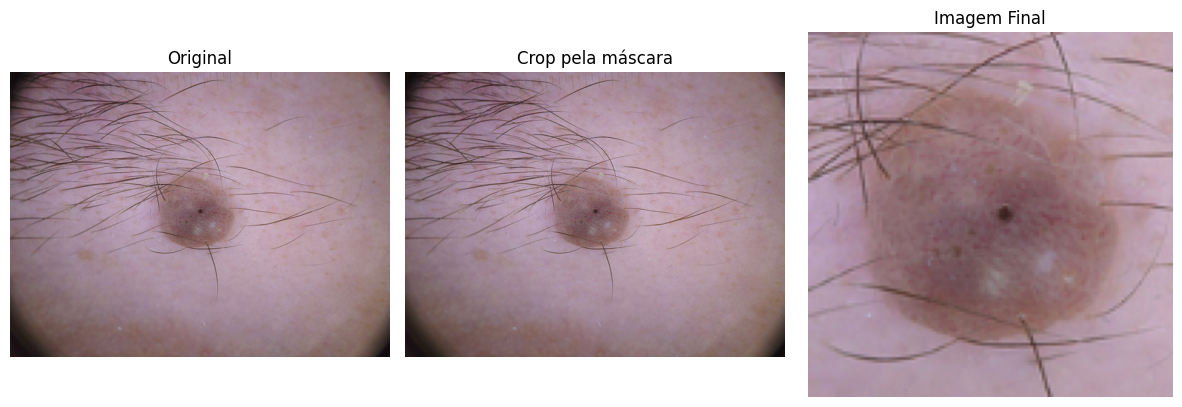

In [6]:
sample_row = train_df.sample(1, random_state=SEED).iloc[0]

original = read_rgb_image(sample_row["image_path"])
dull = dull_razor_remove_hair(original) if USE_DULL_RAZOR else original
final_img = preprocess_image_path(sample_row["image_path"], sample_row["mask_path"])
final_img_uint8 = np.clip(final_img, 0, 255).astype("uint8")

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")
plt.subplot(1, 3, 2)
plt.imshow(dull)
plt.title("Crop pela máscara")
plt.axis("off")
plt.subplot(1, 3, 3)
plt.imshow(final_img_uint8)
plt.title("Imagem Final")
plt.axis("off")
plt.tight_layout()
plt.savefig("pipeline_deepsmote_preprocessamento.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Carregamento das Imagens de Treino em Memória

In [7]:
def load_images_from_df(dataframe, target_size=IMG_SIZE, verbose=True):
    """Carrega todas as imagens de um DataFrame para arrays numpy (normalizado 0-1)."""
    images = []
    labels = []
    failed = 0

    for i, row in dataframe.iterrows():
        try:
            img = preprocess_image_path(row["image_path"], row["mask_path"], target_size)
            img = img / 255.0          # normaliza para [0, 1]
            images.append(img)
            labels.append(row["label"])
        except Exception as e:
            failed += 1
            if verbose:
                print(f"Erro ao carregar {row['image_path']}: {e}")

    X = np.array(images, dtype="float32")
    y = np.array(labels, dtype="int32")

    if verbose:
        print(f"Imagens carregadas: {len(X)}  |  Falhas: {failed}")
        print(f"Shape X: {X.shape}  |  Shape y: {y.shape}")

    return X, y


print("Carregando imagens de TREINO...")
X_train_raw, y_train = load_images_from_df(train_df)

print("\nCarregando imagens de TESTE...")
X_test_raw, y_test = load_images_from_df(test_df)

print("\nDistribuição treino:")
print(Counter(y_train))

Carregando imagens de TREINO...
Imagens carregadas: 8012  |  Falhas: 0
Shape X: (8012, 128, 128, 3)  |  Shape y: (8012,)

Carregando imagens de TESTE...
Imagens carregadas: 2003  |  Falhas: 0
Shape X: (2003, 128, 128, 3)  |  Shape y: (2003,)

Distribuição treino:
Counter({np.int32(1): 5364, np.int32(0): 890, np.int32(4): 879, np.int32(2): 411, np.int32(3): 262, np.int32(6): 114, np.int32(5): 92})


## 7. Autoencoder Convolucional (Encoder + Decoder)

In [8]:
def build_encoder(input_shape=(128, 128, 3), latent_dim=256):
    """
    Encoder: comprime a imagem para um vetor latente de dimensão `latent_dim`.
    Arquitetura: Conv → MaxPool (×4) → Flatten → Dense
    """
    inputs = layers.Input(shape=input_shape, name="encoder_input")

    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D((2, 2))(x)          # 64×64

    x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)          # 32×32

    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)          # 16×16

    x = layers.Conv2D(256, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)          # 8×8

    x = layers.Flatten()(x)
    latent = layers.Dense(latent_dim, activation="relu", name="latent")(x)

    encoder = models.Model(inputs, latent, name="encoder")
    return encoder


def build_decoder(latent_dim=256, output_shape=(128, 128, 3)):
    """
    Decoder: reconstrói a imagem a partir do vetor latente.
    Arquitetura inversa ao encoder: Dense → Reshape → ConvTranspose (×4)
    """
    # Calcula o shape intermediário após 4 maxpool de tamanho 2
    h, w, c = output_shape
    h4, w4 = h // 16, w // 16    # 8×8 para 128×128

    inputs = layers.Input(shape=(latent_dim,), name="decoder_input")

    x = layers.Dense(h4 * w4 * 256, activation="relu")(inputs)
    x = layers.Reshape((h4, w4, 256))(x)        # 8×8×256

    x = layers.Conv2DTranspose(256, (3, 3), activation="relu", padding="same")(x)
    x = layers.UpSampling2D((2, 2))(x)          # 16×16

    x = layers.Conv2DTranspose(128, (3, 3), activation="relu", padding="same")(x)
    x = layers.UpSampling2D((2, 2))(x)          # 32×32

    x = layers.Conv2DTranspose(64, (3, 3), activation="relu", padding="same")(x)
    x = layers.UpSampling2D((2, 2))(x)          # 64×64

    x = layers.Conv2DTranspose(32, (3, 3), activation="relu", padding="same")(x)
    x = layers.UpSampling2D((2, 2))(x)          # 128×128

    outputs = layers.Conv2D(c, (3, 3), activation="sigmoid", padding="same", name="decoder_output")(x)

    decoder = models.Model(inputs, outputs, name="decoder")
    return decoder


def build_autoencoder(encoder, decoder):
    inputs = layers.Input(shape=encoder.input_shape[1:], name="ae_input")
    latent = encoder(inputs)
    reconstructed = decoder(latent)
    autoencoder = models.Model(inputs, reconstructed, name="autoencoder")
    return autoencoder


encoder = build_encoder(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), latent_dim=LATENT_DIM)
decoder = build_decoder(latent_dim=LATENT_DIM, output_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
autoencoder = build_autoencoder(encoder, decoder)

autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="mse"
)

encoder.summary()
decoder.summary()
print("\nParâmetros totais do autoencoder:", autoencoder.count_params())

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 256)            │     4,194,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,582,976 (17.48 MB)

 Trainable params: 4,582,976 (17.48 MB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16384)          │     4,210,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 256)      │       590,080 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 128)    │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 64, 64, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Conv2D)         │ (None, 128, 128, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,188,931 (19.79 MB)

 Trainable params: 5,188,931 (19.79 MB)

 Non-trainable params: 0 (0.00 B)


Parâmetros totais do autoencoder: 9771907


## 8. Treinamento do Autoencoder

Epoch 1/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 76s 350ms/step - loss: 0.0185 - val_loss: 0.0088 - learning_rate: 1.0000e-04
Epoch 2/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 79s 372ms/step - loss: 0.0064 - val_loss: 0.0049 - learning_rate: 1.0000e-04
Epoch 3/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 82s 387ms/step - loss: 0.0043 - val_loss: 0.0039 - learning_rate: 1.0000e-04
Epoch 4/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 91s 429ms/step - loss: 0.0037 - val_loss: 0.0034 - learning_rate: 1.0000e-04
Epoch 5/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 94s 439ms/step - loss: 0.0033 - val_loss: 0.0033 - learning_rate: 1.0000e-04
Epoch 6/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 96s 450ms/step - loss: 0.0030 - val_loss: 0.0029 - learning_rate: 1.0000e-04
Epoch 7/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 97s 457ms/step - loss: 0.0028 - val_loss: 0.0027 - learning_rate: 1.0000e-04
Epoch 8/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 99s 464ms/step - loss: 0.0027 - val_loss: 0.0026 - learning_rate: 1.0000e-04
Epoch 9/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 100s 469ms/step - loss: 

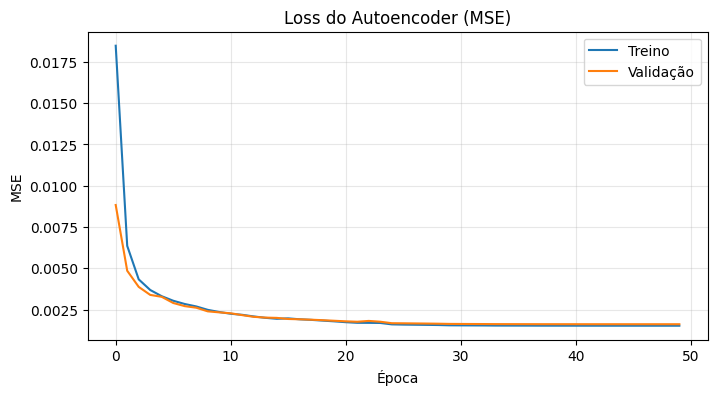

In [9]:
ae_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=4,
        min_lr=1e-7,
        verbose=1
    )
]

ae_history = autoencoder.fit(
    X_train_raw,
    X_train_raw,          # autoencoder: entrada = saída
    validation_split=0.15,
    epochs=AE_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=ae_callbacks,
    verbose=1
)

plt.figure(figsize=(8, 4))
plt.plot(ae_history.history["loss"], label="Treino")
plt.plot(ae_history.history["val_loss"], label="Validação")
plt.title("Loss do Autoencoder (MSE)")
plt.xlabel("Época")
plt.ylabel("MSE")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("loss_autoencoder_deepsmote.png", dpi=300, bbox_inches="tight")
plt.show()

### 8.1 Qualidade da Reconstrução do Autoencoder

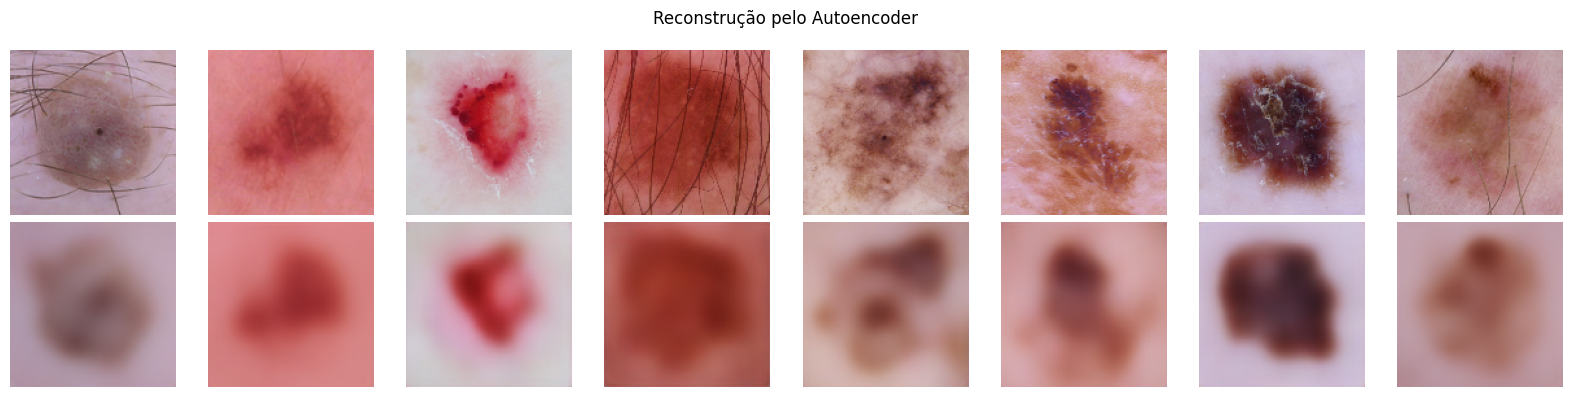

In [10]:
n_samples = 8
sample_idx = np.random.choice(len(X_train_raw), n_samples, replace=False)
sample_imgs = X_train_raw[sample_idx]
reconstructed_imgs = autoencoder.predict(sample_imgs, verbose=0)

plt.figure(figsize=(n_samples * 2, 4))
for i in range(n_samples):
    plt.subplot(2, n_samples, i + 1)
    plt.imshow(sample_imgs[i])
    plt.axis("off")
    if i == 0:
        plt.ylabel("Original", fontsize=10)

    plt.subplot(2, n_samples, n_samples + i + 1)
    plt.imshow(np.clip(reconstructed_imgs[i], 0, 1))
    plt.axis("off")
    if i == 0:
        plt.ylabel("Reconstruída", fontsize=10)

plt.suptitle("Reconstrução pelo Autoencoder", fontsize=12)
plt.tight_layout()
plt.savefig("reconstrucao_autoencoder_deepsmote.png", dpi=300, bbox_inches="tight")
plt.show()

## 9. DeepSMOTE — Geração de Imagens Sintéticas

**Etapas:**
1. Codificar todas as imagens de treino com o `encoder` → vetores latentes
2. Aplicar SMOTE nos vetores latentes (espaço latente) por classe
3. Decodificar os vetores latentes sintéticos com o `decoder` → imagens novas

In [11]:
# Passo 1 — Codificar imagens de treino
print("Codificando imagens de treino para o espaço latente...")
Z_train = encoder.predict(X_train_raw, batch_size=BATCH_SIZE, verbose=1)

print("Shape dos vetores latentes:", Z_train.shape)
print("Distribuição das classes antes do DeepSMOTE:")
print(Counter(y_train))

Codificando imagens de treino para o espaço latente...
251/251 ━━━━━━━━━━━━━━━━━━━━ 15s 60ms/step
Shape dos vetores latentes: (8012, 256)
Distribuição das classes antes do DeepSMOTE:
Counter({np.int32(1): 5364, np.int32(0): 890, np.int32(4): 879, np.int32(2): 411, np.int32(3): 262, np.int32(6): 114, np.int32(5): 92})


In [12]:
# Passo 2 — SMOTE no espaço latente
min_class_count = min(Counter(y_train).values())
k_neighbors = min(5, min_class_count - 1)

print(f"Menor classe no treino: {min_class_count}")
print(f"k_neighbors usado no SMOTE: {k_neighbors}")

smote = SMOTE(random_state=SEED, k_neighbors=k_neighbors)
Z_smote, y_smote = smote.fit_resample(Z_train, y_train)

print("\nShape após SMOTE no espaço latente:", Z_smote.shape)
print("Distribuição após SMOTE:")
print(Counter(y_smote))

# Identificar somente os vetores sintéticos (os adicionados pelo SMOTE)
n_original = len(Z_train)
Z_synthetic = Z_smote[n_original:]
y_synthetic = y_smote[n_original:]

print(f"\nVetores sintéticos gerados: {len(Z_synthetic)}")

Menor classe no treino: 92
k_neighbors usado no SMOTE: 5

Shape após SMOTE no espaço latente: (37548, 256)
Distribuição após SMOTE:
Counter({np.int32(1): 5364, np.int32(0): 5364, np.int32(4): 5364, np.int32(2): 5364, np.int32(5): 5364, np.int32(3): 5364, np.int32(6): 5364})

Vetores sintéticos gerados: 29536


In [13]:
# Passo 3 — Decodificar vetores sintéticos → imagens
print("Decodificando vetores latentes sintéticos para imagens...")
X_synthetic = decoder.predict(Z_synthetic, batch_size=BATCH_SIZE, verbose=1)
X_synthetic = np.clip(X_synthetic, 0.0, 1.0).astype("float32")

print("Shape das imagens sintéticas:", X_synthetic.shape)

# Combinar originais + sintéticas
X_train_augmented = np.concatenate([X_train_raw, X_synthetic], axis=0)
y_train_augmented = np.concatenate([y_train, y_synthetic], axis=0)

print("\nDataset de treino aumentado:")
print("  X shape:", X_train_augmented.shape)
print("  y shape:", y_train_augmented.shape)
print("Distribuição final:", Counter(y_train_augmented))

Decodificando vetores latentes sintéticos para imagens...
923/923 ━━━━━━━━━━━━━━━━━━━━ 89s 96ms/step
Shape das imagens sintéticas: (29536, 128, 128, 3)

Dataset de treino aumentado:
  X shape: (37548, 128, 128, 3)
  y shape: (37548,)
Distribuição final: Counter({np.int32(1): 5364, np.int32(0): 5364, np.int32(4): 5364, np.int32(2): 5364, np.int32(5): 5364, np.int32(3): 5364, np.int32(6): 5364})


### 9.1 Visualização das Imagens Sintéticas Geradas

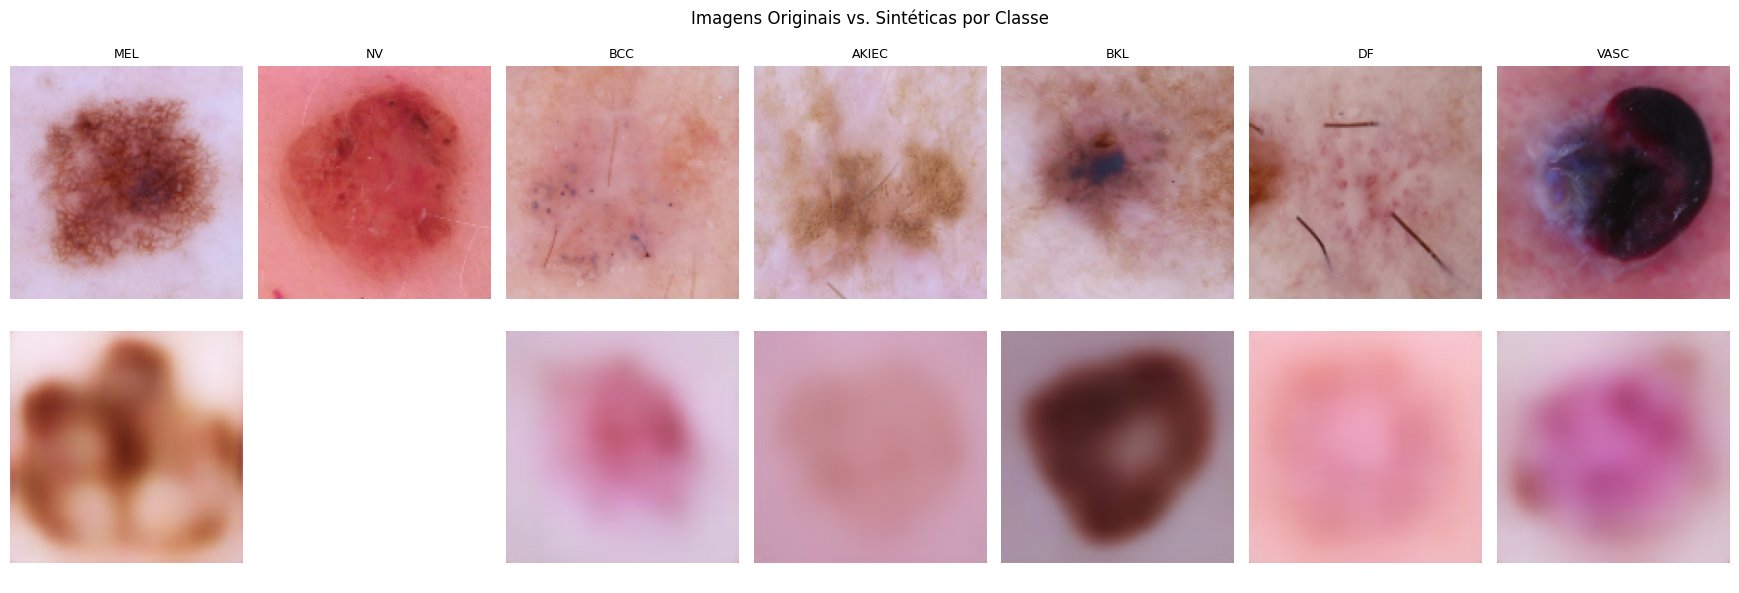

In [14]:
n_cols = 7
fig, axes = plt.subplots(2, n_cols, figsize=(n_cols * 2.5, 6))

for col, cls_idx in enumerate(range(len(classes))):
    # Imagem original de exemplo
    orig_idx = np.where(y_train == cls_idx)[0]
    if len(orig_idx) > 0:
        axes[0, col].imshow(X_train_raw[orig_idx[0]])
    axes[0, col].set_title(classes[cls_idx], fontsize=9)
    axes[0, col].axis("off")

    # Imagem sintética de exemplo
    syn_idx = np.where(y_synthetic == cls_idx)[0]
    if len(syn_idx) > 0:
        axes[1, col].imshow(np.clip(X_synthetic[syn_idx[0]], 0, 1))
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=10)
axes[1, 0].set_ylabel("Sintética (DeepSMOTE)", fontsize=10)

plt.suptitle("Imagens Originais vs. Sintéticas por Classe", fontsize=12)
plt.tight_layout()
plt.savefig("imagens_sinteticas_deepsmote.png", dpi=300, bbox_inches="tight")
plt.show()

## 10. Extração de Features com DenseNet201

Após o aumento de dados, extrai-se features das imagens aumentadas usando DenseNet201 pré-treinada.

In [ ]:
def build_feature_extractor(input_shape=(128, 128, 3)):
    inputs = layers.Input(shape=input_shape)
    x = preprocess_input(inputs * 255.0)   

    base_model = DenseNet201(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape
    )
    base_model.trainable = False

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)

    feature_extractor = models.Model(inputs, x, name="densenet201_feature_extractor")
    return feature_extractor


feature_extractor = build_feature_extractor(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
feature_extractor.summary()

Model: "densenet201_feature_extractor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet201 (Functional)        │ (None, 4, 4, 1920)     │    18,321,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1920)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,321,984 (69.89 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 18,321,984 (69.89 MB)

In [16]:
def extract_features_numpy(X, feature_extractor, batch_size=BATCH_SIZE):
    """Extrai features de um array numpy em lotes."""
    feats = []
    n = len(X)
    for start in range(0, n, batch_size):
        batch = X[start:start + batch_size]
        f = feature_extractor.predict(batch, verbose=0)
        feats.append(f)
    return np.concatenate(feats, axis=0).astype("float32")


print("Extraindo features do conjunto de TREINO AUMENTADO...")
X_train_feats = extract_features_numpy(X_train_augmented, feature_extractor)

print("Extraindo features do conjunto de TESTE...")
X_test_feats = extract_features_numpy(X_test_raw, feature_extractor)

print("X_train_feats:", X_train_feats.shape)
print("X_test_feats:", X_test_feats.shape)

Extraindo features do conjunto de TREINO AUMENTADO...
Extraindo features do conjunto de TESTE...
X_train_feats: (37548, 1920)
X_test_feats: (2003, 1920)


## 11. Divisão Treino / Validação (conjunto aumentado)

In [17]:
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train_feats,
    y_train_augmented,
    test_size=0.20,
    random_state=SEED,
    stratify=y_train_augmented
)

print("Treino para fit:", X_fit.shape)
print("Validação:", X_val.shape)
print("Teste final:", X_test_feats.shape)

print("\nDistribuição fit:")
print(Counter(y_fit))

print("\nDistribuição validação:")
print(Counter(y_val))

Treino para fit: (30038, 1920)
Validação: (7510, 1920)
Teste final: (2003, 1920)

Distribuição fit:
Counter({np.int32(0): 4292, np.int32(4): 4291, np.int32(5): 4291, np.int32(6): 4291, np.int32(2): 4291, np.int32(3): 4291, np.int32(1): 4291})

Distribuição validação:
Counter({np.int32(2): 1073, np.int32(3): 1073, np.int32(6): 1073, np.int32(4): 1073, np.int32(1): 1073, np.int32(5): 1073, np.int32(0): 1072})


## 12. Classificador (Cabeça Densa)

In [18]:
def build_classifier_head(input_dim, num_classes=len(classes)):
    inputs = layers.Input(shape=(input_dim,))

    x = layers.Dense(
        256,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.001)
    )(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.001)
    )(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs, name="deepsmote_densenet201_classifier")
    return model


classifier = build_classifier_head(
    input_dim=X_train_feats.shape[1],
    num_classes=len(classes)
)

classifier.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

classifier.summary()

Model: "deepsmote_densenet201_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 1920)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       491,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 526,599 (2.01 MB)

 Trainable params: 526,087 (2.01 MB)

 Non-trainable params: 512 (2.00 KB)

## 13. Treinamento do Classificador

In [19]:
clf_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=4,
        min_lr=1e-7,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        BEST_CLF_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

clf_history = classifier.fit(
    X_fit,
    y_fit,
    validation_data=(X_val, y_val),
    epochs=CLF_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=clf_callbacks
)

Epoch 1/200
939/939 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4271 - loss: 2.2533
Epoch 1: val_loss improved from None to 1.12267, saving model to best_deepsmote_densenet201_crop.keras

Epoch 1: finished saving model to best_deepsmote_densenet201_crop.keras
939/939 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5356 - loss: 1.7787 - val_accuracy: 0.7296 - val_loss: 1.1227 - learning_rate: 1.0000e-04
Epoch 2/200
919/939 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6545 - loss: 1.3285
Epoch 2: val_loss improved from 1.12267 to 0.98859, saving model to best_deepsmote_densenet201_crop.keras

Epoch 2: finished saving model to best_deepsmote_densenet201_crop.keras
939/939 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6704 - loss: 1.2721 - val_accuracy: 0.7679 - val_loss: 0.9886 - learning_rate: 1.0000e-04
Epoch 3/200
922/939 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7030 - loss: 1.1588
Epoch 3: val_loss improved from 0.98859 to 0.89976, saving model to best_deepsmote_densenet201

### 13.1 Curvas de Treinamento

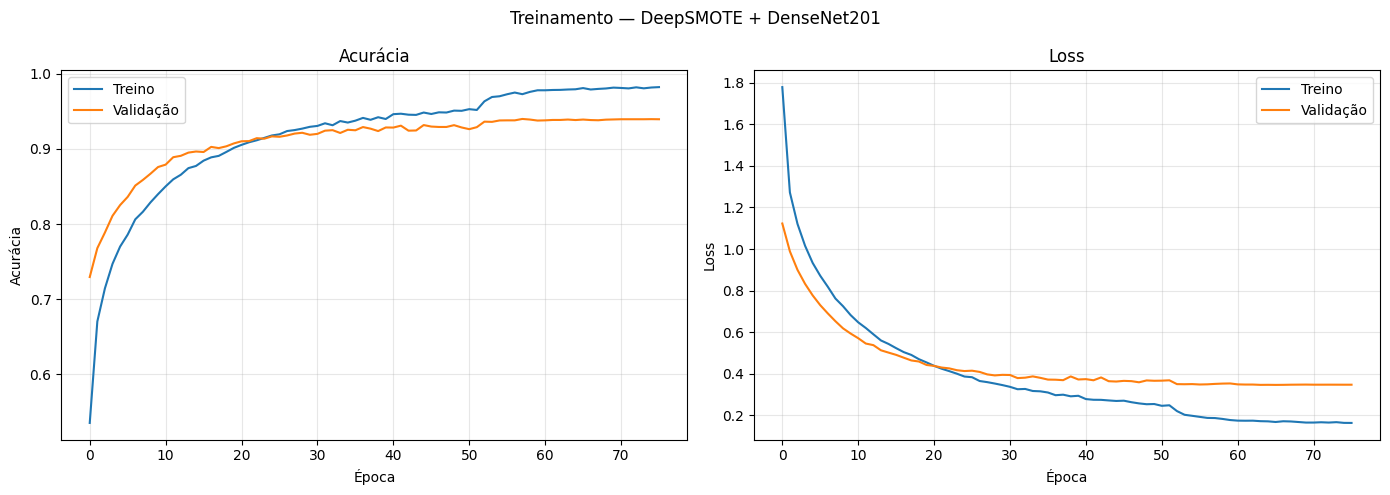

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(clf_history.history["accuracy"], label="Treino")
axes[0].plot(clf_history.history["val_accuracy"], label="Validação")
axes[0].set_title("Acurácia")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Acurácia")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(clf_history.history["loss"], label="Treino")
axes[1].plot(clf_history.history["val_loss"], label="Validação")
axes[1].set_title("Loss")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Treinamento — DeepSMOTE + DenseNet201", fontsize=12)
plt.tight_layout()
plt.savefig("curvas_treinamento_deepsmote.png", dpi=300, bbox_inches="tight")
plt.show()

## 14. Avaliação no Conjunto de Teste

In [21]:
best_classifier = keras.models.load_model(BEST_CLF_PATH)

pred_probs = best_classifier.predict(X_test_feats, verbose=0)
y_pred = np.argmax(pred_probs, axis=1)

print("Relatório de Classificação:")
print(classification_report(
    y_test,
    y_pred,
    target_names=classes,
    digits=4,
    zero_division=0
))

acc = accuracy_score(y_test, y_pred)

macro_precision  = precision_score(y_test, y_pred, average="macro",    zero_division=0)
macro_recall     = recall_score(   y_test, y_pred, average="macro",    zero_division=0)
macro_f1         = f1_score(       y_test, y_pred, average="macro",    zero_division=0)

weighted_precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
weighted_recall    = recall_score(   y_test, y_pred, average="weighted", zero_division=0)
weighted_f1        = f1_score(       y_test, y_pred, average="weighted", zero_division=0)

print("\nMÉTRICAS GERAIS DO MODELO — DeepSMOTE + DenseNet201")
print(f"Accuracy: {acc:.4f}")
print("\nMacro Average:")
print(f"  Precision: {macro_precision:.4f}")
print(f"  Recall:    {macro_recall:.4f}")
print(f"  F1-Score:  {macro_f1:.4f}")
print("\nWeighted Average:")
print(f"  Precision: {weighted_precision:.4f}")
print(f"  Recall:    {weighted_recall:.4f}")
print(f"  F1-Score:  {weighted_f1:.4f}")

Relatório de Classificação:
              precision    recall  f1-score   support

         MEL     0.6286    0.4933    0.5528       223
          NV     0.8900    0.9597    0.9236      1341
         BCC     0.7027    0.7573    0.7290       103
       AKIEC     0.4915    0.4462    0.4677        65
         BKL     0.6879    0.5409    0.6056       220
          DF     0.7692    0.4348    0.5556        23
        VASC     0.8462    0.7857    0.8148        28

    accuracy                         0.8263      2003
   macro avg     0.7166    0.6311    0.6641      2003
weighted avg     0.8142    0.8263    0.8168      2003


MÉTRICAS GERAIS DO MODELO — DeepSMOTE + DenseNet201
Accuracy: 0.8263

Macro Average:
  Precision: 0.7166
  Recall:    0.6311
  F1-Score:  0.6641

Weighted Average:
  Precision: 0.8142
  Recall:    0.8263
  F1-Score:  0.8168


### 14.1 Matriz de Confusão

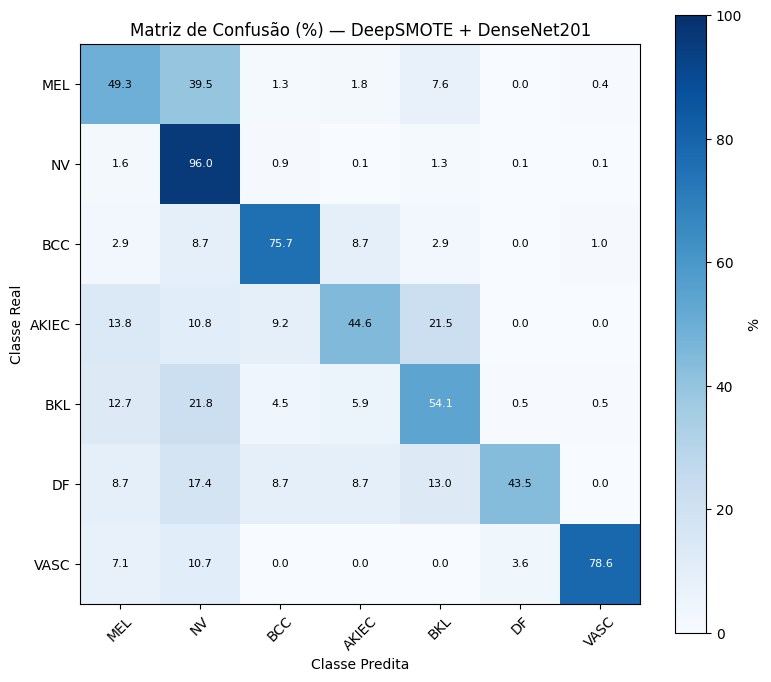

In [22]:
cm = confusion_matrix(y_test, y_pred, labels=list(range(len(classes))))
cm_percent = cm.astype("float") / cm.sum(axis=1, keepdims=True) * 100
cm_percent = np.nan_to_num(cm_percent)

plt.figure(figsize=(8, 7))
im = plt.imshow(cm_percent, interpolation="nearest", cmap="Blues", vmin=0, vmax=100)
plt.title("Matriz de Confusão (%) — DeepSMOTE + DenseNet201")
plt.colorbar(im, label="%")

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

for i in range(cm_percent.shape[0]):
    for j in range(cm_percent.shape[1]):
        color = "white" if cm_percent[i, j] > 50 else "black"
        plt.text(j, i, f"{cm_percent[i, j]:.1f}",
                 ha="center", va="center", color=color, fontsize=8)

plt.ylabel("Classe Real")
plt.xlabel("Classe Predita")
plt.tight_layout()
plt.savefig("matriz_confusao_deepsmote.png", dpi=300, bbox_inches="tight")
plt.show()

### 14.2 Exemplos Corretos e Incorretos

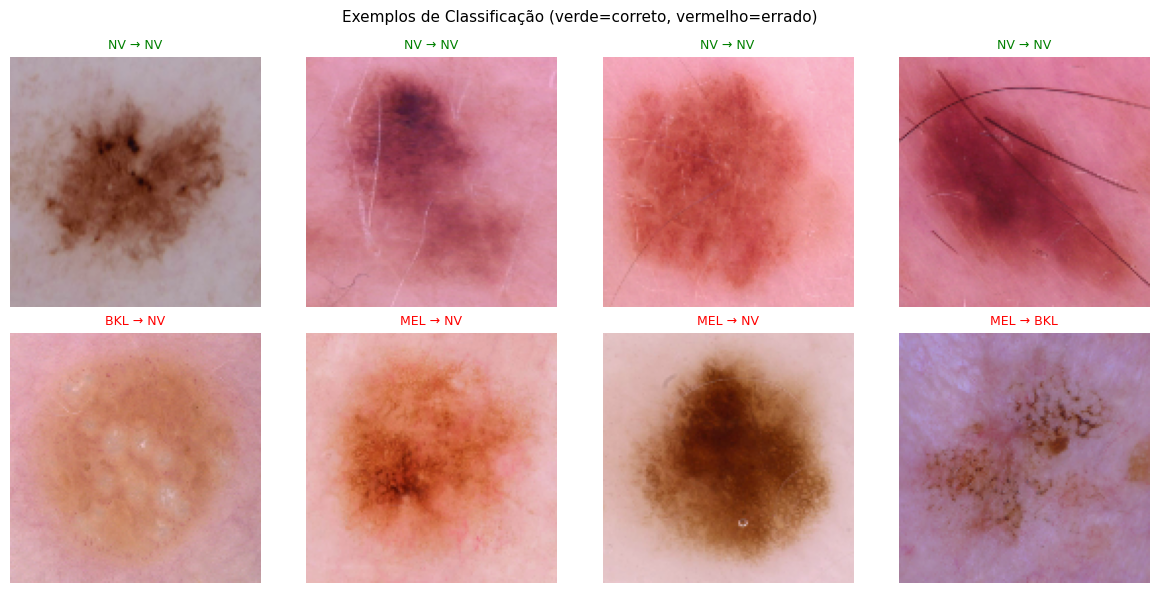

In [23]:
test_eval_df = test_df.copy().reset_index(drop=True)
test_eval_df["y_true"] = y_test
test_eval_df["y_pred"] = y_pred
test_eval_df["correct"] = test_eval_df["y_true"] == test_eval_df["y_pred"]

correct_samples   = test_eval_df[test_eval_df["correct"]].head(4)
incorrect_samples = test_eval_df[~test_eval_df["correct"]].head(4)
samples_to_plot   = pd.concat([correct_samples, incorrect_samples]).reset_index(drop=True)

plt.figure(figsize=(12, 6))
for i, row in samples_to_plot.iterrows():
    image = preprocess_image_path(row["image_path"], row["mask_path"])
    image = np.clip(image, 0, 255).astype("uint8")

    plt.subplot(2, 4, i + 1)
    plt.imshow(image)
    true_label = class_name[int(row["y_true"])]
    pred_label = class_name[int(row["y_pred"])]
    color = "green" if row["correct"] else "red"
    plt.title(f"{true_label} → {pred_label}", fontsize=9, color=color)
    plt.axis("off")

plt.suptitle("Exemplos de Classificação (verde=correto, vermelho=errado)", fontsize=11)
plt.tight_layout()
plt.savefig("exemplos_classificacao_deepsmote.png", dpi=300, bbox_inches="tight")
plt.show()

## 15. Salvando os Modelos

In [24]:
encoder.save(ENCODER_PATH)
decoder.save(DECODER_PATH)
autoencoder.save(AUTOENCODER_PATH)
best_classifier.save(FINAL_CLF_PATH)

print("Encoder salvo em:",      ENCODER_PATH)
print("Decoder salvo em:",      DECODER_PATH)
print("Autoencoder salvo em:",  AUTOENCODER_PATH)
print("Melhor checkpoint:",     BEST_CLF_PATH)
print("Classificador final:",   FINAL_CLF_PATH)

Encoder salvo em: deepsmote_encoder_densenet201_crop.keras
Decoder salvo em: deepsmote_decoder_densenet201_crop.keras
Autoencoder salvo em: deepsmote_autoencoder_densenet201_crop.keras
Melhor checkpoint: best_deepsmote_densenet201_crop.keras
Classificador final: deepsmote_densenet201_crop_final.keras
